<a href="https://colab.research.google.com/github/AtreoP/Atreo/blob/main/Copy_of_TASK_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Task` Train a KNN model on glass type dataset and find best n_neighnours.

Data Link: https://drive.google.com/file/d/17cbDNBmys04MJqQfrma3jd72VPMnxIq0/view?usp=share_link

# Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('./sample_data/glass.csv')

In [ ]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
df.shape

(214, 10)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1],test_size=0.2, random_state=2)

In [ ]:
X_train.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
213,1.51711,14.23,0.00,2.08,73.36,0.00,8.62,1.67,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
164,1.51915,12.73,1.85,1.86,72.69,0.60,10.09,0.00,0.0
14,1.51763,12.61,3.59,1.31,73.29,0.58,8.50,0.00,0.0


In [ ]:
X_train.shape

(171, 9)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train

array([[-0.72333174,  0.10969725,  0.60674727, ..., -0.86643887,
        -0.35407712, -0.573292  ],
       [-0.42662953,  0.94128435, -1.86010645, ..., -0.26907265,
         3.21128975, -0.573292  ],
       [-0.25116048, -0.27045686,  0.70403164, ..., -0.55353275,
        -0.35407712, -0.573292  ],
       ...,
       [-0.80309039, -0.41301465,  0.6345428 , ..., -0.83088136,
        -0.35407712, -0.573292  ],
       [-0.26711221, -0.74564949,  0.59979838, ..., -0.43263721,
        -0.35407712, -0.573292  ],
       [-0.57019511, -0.68625041, -1.86010645, ...,  0.83321027,
        -0.35407712, -0.573292  ]])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

scores = []

for i in range(1,16):

    knn = KNeighborsClassifier(n_neighbors=i)

    knn.fit(X_train,y_train)

    y_pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))
print(scores)

[0.6976744186046512, 0.627906976744186, 0.7209302325581395, 0.6976744186046512, 0.7209302325581395, 0.7209302325581395, 0.7209302325581395, 0.6976744186046512, 0.6976744186046512, 0.7209302325581395, 0.6976744186046512, 0.7441860465116279, 0.7441860465116279, 0.7674418604651163, 0.7441860465116279]


In [ ]:
y_train

,Type
2,1
213,7
3,1
164,5
14,1
...,...
43,1
22,1
72,2
15,1


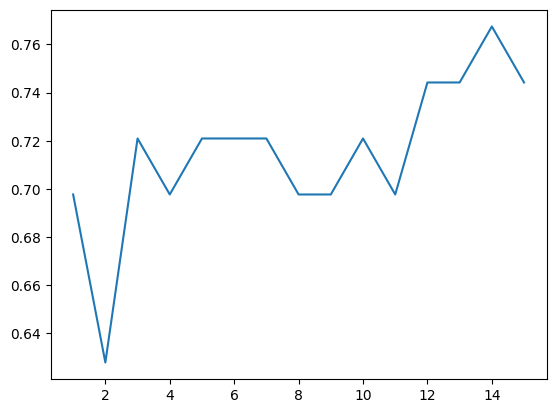

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1,16),scores)